## Get HRV-LF/HV ratio for all subs

-open question: take v1/v2 or v1raw or v2raw ? 
--> currently raw version does not work (no peaks detected for some runs)

In [2]:
import neurokit2 as nk
import pandas as pd
import numpy as np
import os.path as op
import os
import matplotlib.pyplot as plt
import seaborn as sns

bids_folder = '/mnt_01/ds-stressrisk'
subList = [f[4:] for f in os.listdir(bids_folder) if f[0:3] == 'sub']
target_folder = op.join(bids_folder, 'interim_sum_data')

In [3]:
group_list = pd.read_csv(op.join(bids_folder, 'group_assignmentList.csv'))[['subject', 'group']].set_index('subject')   
group_list.head()

,group
subject,
1,0
2,0
3,1
4,1
5,0


/home/ubuntu/miniconda3/envs/basic_env_stressrisk_ana/lib/python3.13/site-packages/neurokit2/ecg/ecg_clean.py:106: NeuroKitWarning: There are 1 missing data points in your signal. Filling missing values by using the forward filling method.
  warn(
/home/ubuntu/miniconda3/envs/basic_env_stressrisk_ana/lib/python3.13/site-packages/neurokit2/ecg/ecg_clean.py:165: FutureWarning: DataFrame.pad/Series.pad is deprecated. Use DataFrame.ffill/Series.ffill instead
  ecg_signal = pd.DataFrame.pad(pd.Series(ecg_signal))


0    1.301115
Name: HRV_LFHF, dtype: float64


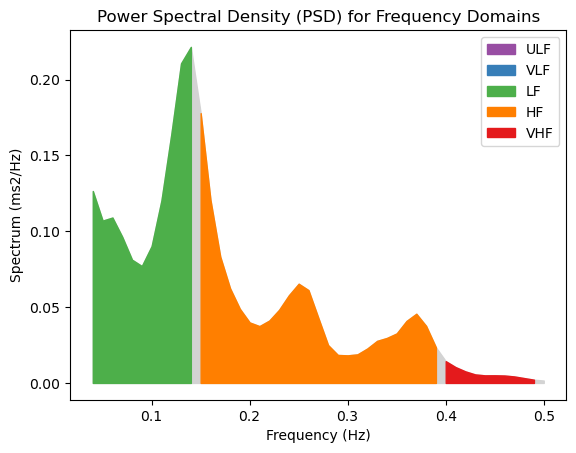

In [4]:
var = 'v1'
sampling_rate = 500

sub = '01'
ses = 1
run = 2
fn = op.join(bids_folder, f'sub-{sub}', f'ses-{ses}', 'func', f'sub-{sub}_ses-{ses}_task-risk_run-{run}_physio.log')
df_physio = pd.read_csv(fn, sep=r'\s+', header=4,low_memory=False, dtype=str) # '\t' #  delim_whitespace=True,
df_physio.columns = list(df_physio.columns[1:]) + ['']
df_physio = df_physio.drop(columns='')


signals, info = nk.ecg_process( pd.to_numeric(df_physio[var]).values, sampling_rate=sampling_rate)
ecg_signal = signals['ECG_Clean'].values

peaks, info = nk.ecg_peaks(ecg_signal, sampling_rate=sampling_rate)
#hrv_time = nk.hrv_time(peaks, sampling_rate=sampling_rate, show=True)
hrv_freq = nk.hrv_frequency(peaks, sampling_rate=sampling_rate, show=True, normalize=True)
hrv_lfhf =  hrv_freq['HRV_LFHF']
print(hrv_lfhf)

In [ ]:
var = 'v1'
sampling_rate = 500

data = []

for sub in subList:
    for ses in [1,2]:
        for run in range(1,7):
            try: 
                fn = op.join(bids_folder, f'sub-{sub}', f'ses-{ses}', 'func', f'sub-{sub}_ses-{ses}_task-risk_run-{run}_physio.log')
                df_physio = pd.read_csv(fn, sep=r'\s+', header=4, dtype=str) # '\t' #  delim_whitespace=True,, dtype=str
                df_physio.columns = list(df_physio.columns[1:]) + ['']
                df_physio = df_physio.drop(columns='')
                #df_physio = df_physio.dropna(subset=[var]) # problematic?
                
                signals, info = nk.ecg_process( pd.to_numeric(df_physio[var], errors='coerce').values, sampling_rate=sampling_rate)
                ecg_signal = signals['ECG_Clean'].values
                peaks, info = nk.ecg_peaks(ecg_signal, sampling_rate=sampling_rate)

                #hrv_time = nk.hrv_time(peaks, sampling_rate=sampling_rate, show=True)
                hrv_freq = nk.hrv_frequency(peaks, sampling_rate=sampling_rate, show=False, normalize=True)
                hrv_lfhf =  hrv_freq['HRV_LFHF'].values[0]
                data.append({'subject': sub, 'session': ses, 'run': run, 'HRV_LFHF': hrv_lfhf})
                #plt.close('all')
                print(f'Done: {sub} {ses} {run}')

            except:
                print(f'Error: {sub} {ses} {run}')
df = pd.DataFrame(data)
df.to_csv(op.join(target_folder, f'HRV_var-{var}_sampRate-{sampling_rate}_LFHF_subwise.csv'))
df.head()


/home/ubuntu/miniconda3/envs/basic_env_stressrisk_ana/lib/python3.13/site-packages/neurokit2/ecg/ecg_clean.py:106: NeuroKitWarning: There are 1 missing data points in your signal. Filling missing values by using the forward filling method.
  warn(
/home/ubuntu/miniconda3/envs/basic_env_stressrisk_ana/lib/python3.13/site-packages/neurokit2/ecg/ecg_clean.py:165: FutureWarning: DataFrame.pad/Series.pad is deprecated. Use DataFrame.ffill/Series.ffill instead
  ecg_signal = pd.DataFrame.pad(pd.Series(ecg_signal))


Done: 12 1 1


/home/ubuntu/miniconda3/envs/basic_env_stressrisk_ana/lib/python3.13/site-packages/neurokit2/ecg/ecg_clean.py:106: NeuroKitWarning: There are 1 missing data points in your signal. Filling missing values by using the forward filling method.
  warn(
/home/ubuntu/miniconda3/envs/basic_env_stressrisk_ana/lib/python3.13/site-packages/neurokit2/ecg/ecg_clean.py:165: FutureWarning: DataFrame.pad/Series.pad is deprecated. Use DataFrame.ffill/Series.ffill instead
  ecg_signal = pd.DataFrame.pad(pd.Series(ecg_signal))


Done: 12 1 2


/home/ubuntu/miniconda3/envs/basic_env_stressrisk_ana/lib/python3.13/site-packages/neurokit2/ecg/ecg_clean.py:106: NeuroKitWarning: There are 1 missing data points in your signal. Filling missing values by using the forward filling method.
  warn(
/home/ubuntu/miniconda3/envs/basic_env_stressrisk_ana/lib/python3.13/site-packages/neurokit2/ecg/ecg_clean.py:165: FutureWarning: DataFrame.pad/Series.pad is deprecated. Use DataFrame.ffill/Series.ffill instead
  ecg_signal = pd.DataFrame.pad(pd.Series(ecg_signal))


...

/home/ubuntu/miniconda3/envs/basic_env_stressrisk_ana/lib/python3.13/site-packages/neurokit2/ecg/ecg_clean.py:106: NeuroKitWarning: There are 1 missing data points in your signal. Filling missing values by using the forward filling method.
  warn(
/home/ubuntu/miniconda3/envs/basic_env_stressrisk_ana/lib/python3.13/site-packages/neurokit2/ecg/ecg_clean.py:165: FutureWarning: DataFrame.pad/Series.pad is deprecated. Use DataFrame.ffill/Series.ffill instead
  ecg_signal = pd.DataFrame.pad(pd.Series(ecg_signal))


Error: 12 1 6


/home/ubuntu/miniconda3/envs/basic_env_stressrisk_ana/lib/python3.13/site-packages/neurokit2/ecg/ecg_clean.py:106: NeuroKitWarning: There are 1 missing data points in your signal. Filling missing values by using the forward filling method.
  warn(
/home/ubuntu/miniconda3/envs/basic_env_stressrisk_ana/lib/python3.13/site-packages/neurokit2/ecg/ecg_clean.py:165: FutureWarning: DataFrame.pad/Series.pad is deprecated. Use DataFrame.ffill/Series.ffill instead
  ecg_signal = pd.DataFrame.pad(pd.Series(ecg_signal))


Done: 12 2 1


/home/ubuntu/miniconda3/envs/basic_env_stressrisk_ana/lib/python3.13/site-packages/neurokit2/ecg/ecg_clean.py:106: NeuroKitWarning: There are 1 missing data points in your signal. Filling missing values by using the forward filling method.
  warn(
/home/ubuntu/miniconda3/envs/basic_env_stressrisk_ana/lib/python3.13/site-packages/neurokit2/ecg/ecg_clean.py:165: FutureWarning: DataFrame.pad/Series.pad is deprecated. Use DataFrame.ffill/Series.ffill instead
  ecg_signal = pd.DataFrame.pad(pd.Series(ecg_signal))


In [ ]:
var = 'v1'
sampling_rate = 500
df = pd.read_csv(op.join(target_folder, f'HRV_var-{var}_sampRate-{sampling_rate}_LFHF_subwise.csv')).drop('Unnamed: 0', axis=1) # withour cleaning DF-name without 'sampRate'
df['subject'] = df['subject'].astype(int)
df = df.set_index(['subject','session','run']).join(group_list, on='subject').set_index('group', append=True)   


/home/ubuntu/miniconda3/envs/basic_env_stressrisk_ana/lib/python3.13/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/ubuntu/miniconda3/envs/basic_env_stressrisk_ana/lib/python3.13/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/ubuntu/miniconda3/envs/basic_env_stressrisk_ana/lib/python3.13/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


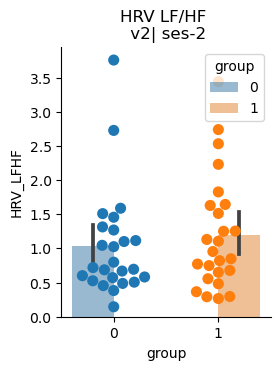

In [ ]:
ses = 2
tmp = df.groupby(['subject','session','group']).mean().xs(ses,0,level='session')

plt.figure(figsize=(2.7,3.5)) 
ax = sns.barplot(data=tmp.reset_index(), x ='group', hue='group',y='HRV_LFHF', alpha=0.5)
sns.swarmplot(data=tmp.reset_index(), x='group', hue='group', y='HRV_LFHF', size=8,legend=False)

ax.set(title=f'HRV LF/HF \n {var}| ses-{ses}')
sns.despine()

/home/ubuntu/miniconda3/envs/basic_env_stressrisk_ana/lib/python3.13/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/ubuntu/miniconda3/envs/basic_env_stressrisk_ana/lib/python3.13/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/ubuntu/miniconda3/envs/basic_env_stressrisk_ana/lib/python3.13/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/ubuntu/miniconda3/envs/basic_

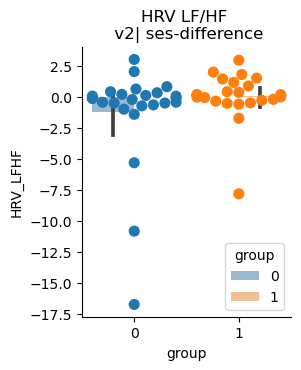

In [47]:
ses = 'difference'
tmp = df.groupby(['subject','session','group']).mean().xs(2,0,level='session') - df.groupby(['subject','session','group']).mean().xs(1,0,level='session')

plt.figure(figsize=(2.7,3.5)) 
ax = sns.barplot(data=tmp.reset_index(), x ='group', hue='group',y='HRV_LFHF', alpha=0.5)
sns.swarmplot(data=tmp.reset_index(), x='group', hue='group', y='HRV_LFHF', size=8,legend=False)

ax.set(title=f'HRV LF/HF \n {var}| ses-{ses}')
sns.despine()